In [196]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

In [197]:
data_obj = pd.read_csv('housing.csv')

In [198]:
data_obj

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND


In [199]:
#Effectively visualizes the descriptive statistics of the given DataFrame. This includes min, max, mean, median, standard deviation. 
data_obj.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [200]:
# So we can see that the 'total_bedrooms' column contains some nan values
data_obj.isnull().any()

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
total_bedrooms         True
population            False
households            False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool

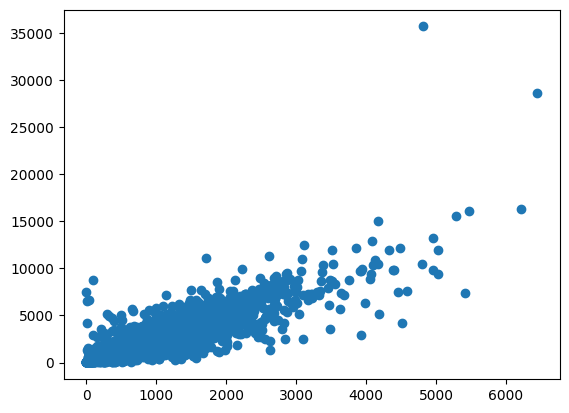

In [201]:
# Plotting total_bedrooms vs population BEFORE filling in the nan values with the mean
plt.scatter(data_obj.total_bedrooms, data_obj.population)

In [202]:
data_obj.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [203]:
total_bedroom_mean = np.mean(data_obj.total_bedrooms)
total_bedroom_mean

537.8705525375618

In [204]:
data_obj.total_bedrooms.fillna(value = total_bedroom_mean, inplace = True)

In [205]:
data_obj.isnull().any()

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
total_bedrooms        False
population            False
households            False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool

All nan values successfully replaced with mean

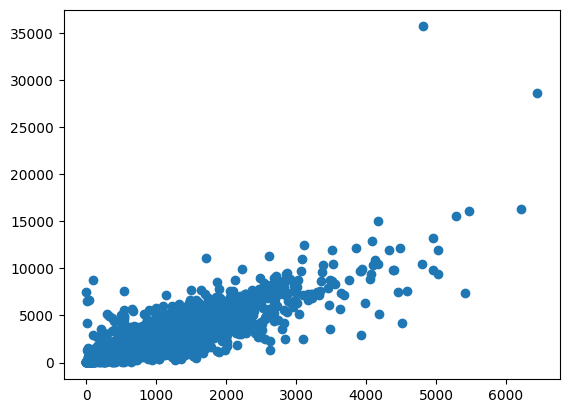

In [206]:
# Plotting total_bedrooms vs population AFTER filling in the nan values with the mean
plt.scatter(data_obj.total_bedrooms, data_obj.population)

In [207]:
# Dropping duplicates
data_obj.drop_duplicates(inplace= True)

In [208]:
data_obj

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND


In [209]:
# As the number of rows and columns remains unchanged, there seem to be no duplicates.

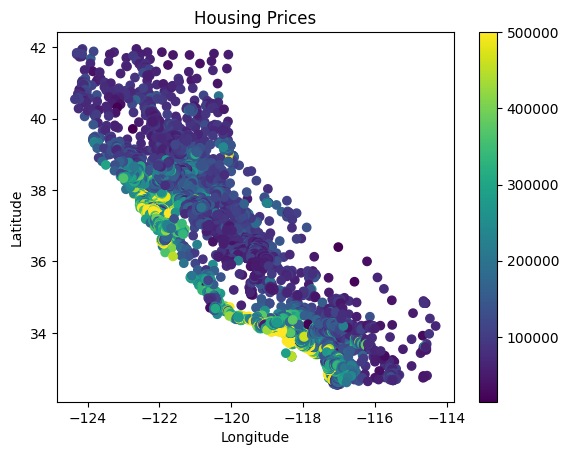

In [210]:
plt.scatter(data_obj.longitude , data_obj.latitude, c = data_obj.median_house_value)
plt.title('Housing Prices')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.colorbar()

plt.show()

In [211]:
df = data_obj.query('housing_median_age	<= 10 and median_house_value >= 264725.000000 and ocean_proximity == "<1H OCEAN"')

In [212]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
863,-122.00,37.58,6,4405,717.0,2071,688,5.8151,295600,<1H OCEAN
870,-121.93,37.49,5,1150,311.0,648,245,3.5714,300000,<1H OCEAN
922,-121.92,37.53,7,28258,3864.0,12203,3701,8.4045,451100,<1H OCEAN
923,-121.89,37.49,9,4909,577.0,1981,591,9.7194,500001,<1H OCEAN
946,-121.92,37.72,4,7477,1576.0,2937,1506,5.1437,299400,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
20440,-118.77,34.24,6,16222,2309.0,6700,2080,6.4963,308100,<1H OCEAN
20450,-118.91,34.28,6,6106,1134.0,3246,1062,5.2206,280200,<1H OCEAN
20451,-118.90,34.26,5,25187,3521.0,11956,3478,6.9712,321300,<1H OCEAN
20487,-118.67,34.30,5,6123,825.0,2440,736,7.9013,393000,<1H OCEAN


Text(0.5, 1.0, 'Plot of relatively newer houses (<=10y) that are close to the ocean and in the top 25%ile in terms of pricing')

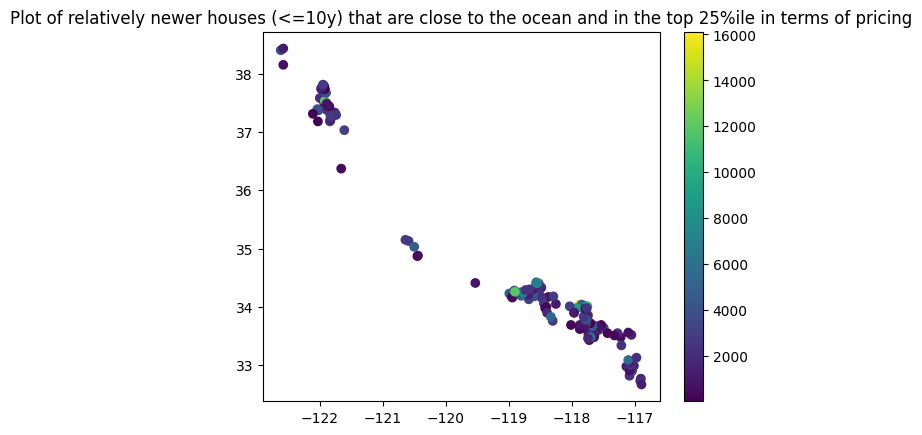

In [213]:
plt.scatter(df.longitude, df.latitude, c= df.population)
plt.colorbar()
plt.title('Plot of relatively newer houses (<=10y) that are close to the ocean and in the top 25%ile in terms of pricing')

In [214]:
grouped = data_obj.groupby('ocean_proximity') 
#encoding the values into labels. 
ocean_proximity_le = LabelEncoder() 
data_obj.ocean_proximity = ocean_proximity_le.fit_transform(data_obj.ocean_proximity)

In [215]:
data_obj

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,3
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,3
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,3
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,3
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,1
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,1
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,1
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,1


In [216]:
# Exploratory data analysis by (on subgroups): 

In [217]:
df_1 = data_obj.query('ocean_proximity == "<1H OCEAN"')
df_1.describe()
#HOUSES WITH A PROXIMITY OF <1H FROM THE OCEAN

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


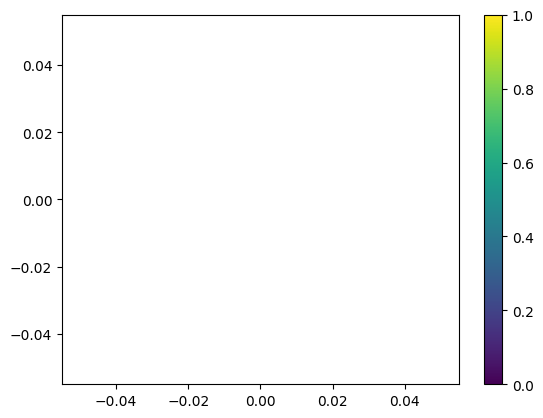

In [218]:
plt.scatter(df_1.longitude, df_1.latitude, c = df_1.median_house_value)
plt.colorbar()

In [219]:
df_2 = data_obj.query('ocean_proximity == "INLAND"')
df_2.describe()
# INLAND HOUSES

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


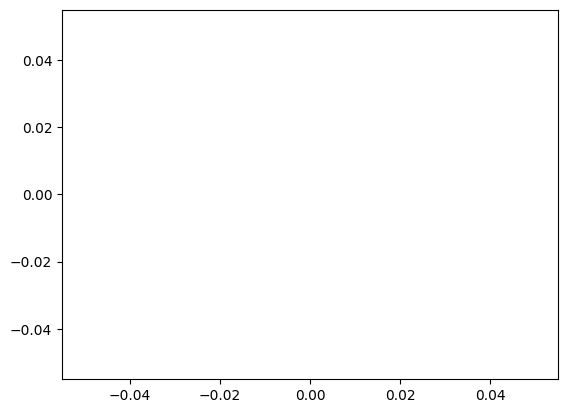

In [220]:
plt.scatter(df_2.longitude, df_2.latitude)

In [221]:
df_3 = data_obj.query('ocean_proximity == "NEAR OCEAN"')
df_3.describe()
#HOUSES NEAR THE OCEAN

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


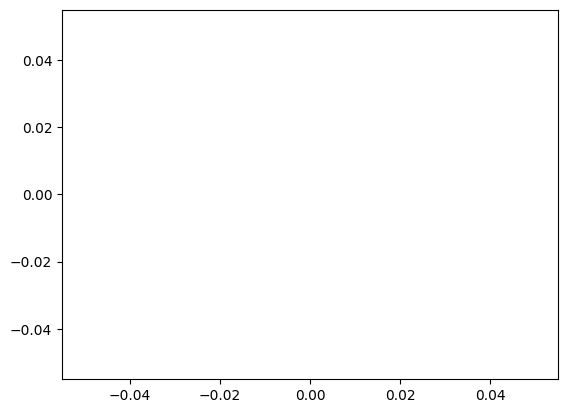

In [222]:
plt.scatter(df_3.longitude, df_3.latitude)

In [223]:
data = data_obj
#grouping the given DataFrame according to ‘ocean_proximity. 
grouped = data.groupby('ocean_proximity') 
#encoding the values into labels. 
ocean_proximity_le = LabelEncoder() 
data['ocean_proximity'] = ocean_proximity_le.fit_transform(data['ocean_proximity'])

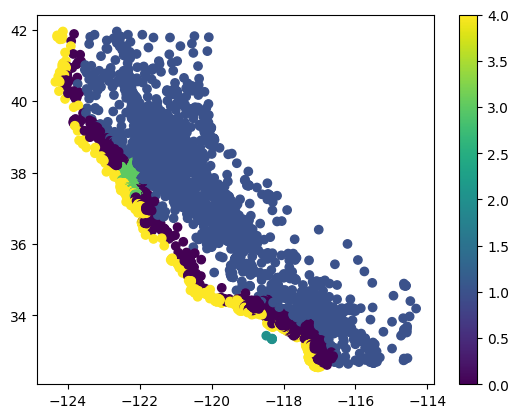

In [224]:
plt.scatter(data.longitude, data.latitude, c = data.ocean_proximity)
plt.colorbar()

In [225]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,3
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,3
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,3
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,3
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,1
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,1
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,1
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,1


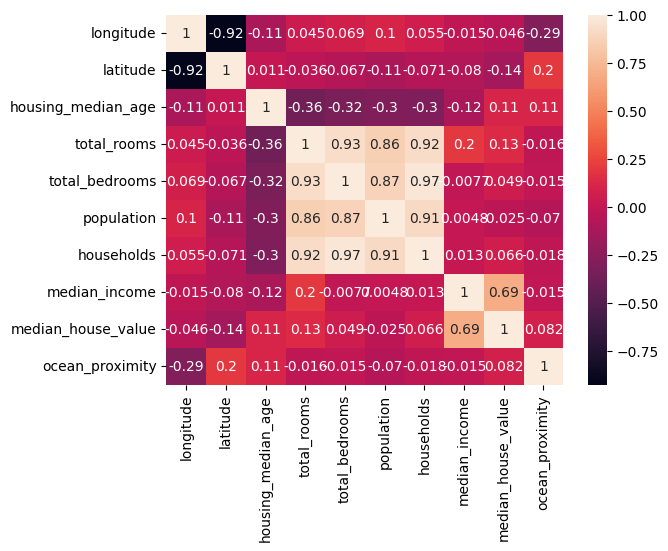

In [226]:
sns.heatmap(data.corr(), annot = True)
plt.show()
# SLOPE HEAVY

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'longitude'),
  Text(1, 0, 'latitude'),
  Text(2, 0, 'housing_median_age'),
  Text(3, 0, 'total_rooms'),
  Text(4, 0, 'total_bedrooms'),
  Text(5, 0, 'population'),
  Text(6, 0, 'households'),
  Text(7, 0, 'median_income'),
  Text(8, 0, 'median_house_value'),
  Text(9, 0, 'ocean_proximity')])

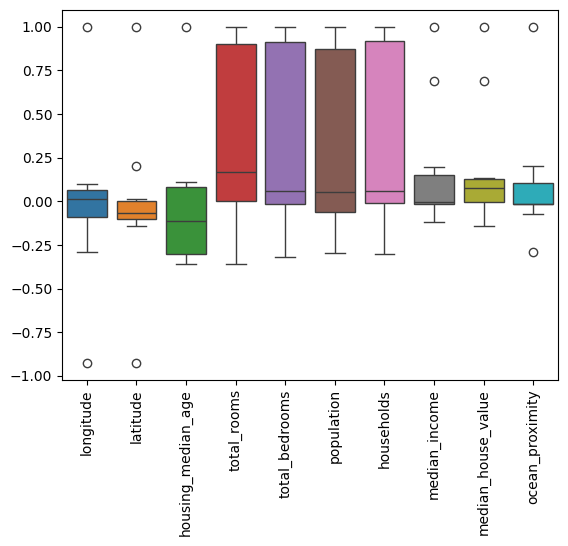

In [227]:
sns.boxplot(data.corr())
plt.xticks(rotation = 90)

11.C,D
12
13
14 remaining

In [228]:
data_obj.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,1.165843
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874,1.420662
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000,0.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000,1.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000,1.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,4.000000


In [229]:
x_75 = data_obj.median_house_value.quantile(0.90)

In [230]:
data_premium = data_obj.query(f'median_house_value >= {x_75}')

In [231]:
data_premium

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,3
89,-122.27,37.80,52,249,78.0,396,85,1.2434,500001,3
123,-122.24,37.84,52,3529,574.0,1177,555,5.1773,389500,3
124,-122.24,37.85,52,2612,365.0,901,367,7.2354,391100,3
128,-122.21,37.83,40,4991,674.0,1616,654,7.5544,411500,3
...,...,...,...,...,...,...,...,...,...,...
20436,-118.69,34.21,10,3663,409.0,1179,371,12.5420,500001,0
20438,-118.79,34.26,17,1986,249.0,761,241,7.2137,401900,0
20442,-118.78,34.25,13,1841,237.0,833,231,7.7785,404700,0
20443,-118.85,34.27,50,187,33.0,130,35,3.3438,500001,0


In [232]:
data_premium

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,3
89,-122.27,37.80,52,249,78.0,396,85,1.2434,500001,3
123,-122.24,37.84,52,3529,574.0,1177,555,5.1773,389500,3
124,-122.24,37.85,52,2612,365.0,901,367,7.2354,391100,3
128,-122.21,37.83,40,4991,674.0,1616,654,7.5544,411500,3
...,...,...,...,...,...,...,...,...,...,...
20436,-118.69,34.21,10,3663,409.0,1179,371,12.5420,500001,0
20438,-118.79,34.26,17,1986,249.0,761,241,7.2137,401900,0
20442,-118.78,34.25,13,1841,237.0,833,231,7.7785,404700,0
20443,-118.85,34.27,50,187,33.0,130,35,3.3438,500001,0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'longitude'),
  Text(1, 0, 'latitude'),
  Text(2, 0, 'housing_median_age'),
  Text(3, 0, 'total_rooms'),
  Text(4, 0, 'total_bedrooms'),
  Text(5, 0, 'population'),
  Text(6, 0, 'households'),
  Text(7, 0, 'median_income'),
  Text(8, 0, 'median_house_value'),
  Text(9, 0, 'ocean_proximity')])

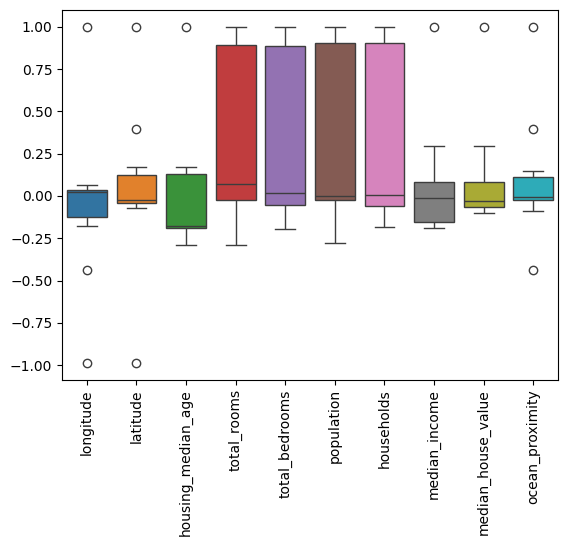

In [233]:
# Premium house boxplot
sns.boxplot(data_premium.corr())
plt.xticks(rotation = 90)